<a href="https://colab.research.google.com/github/ChristineHarvey/InformationLossScore/blob/main/multiclinsum_prototype_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


MULTICLINSUM INFORMATION LOSS ANALYSIS SCORE


End-to-end NLP pipeline for measuring information loss between Full Clinical Reports and their associated Clinical Summaries, using the MultiClinSum v8 dataset.


PIPELINE


1. Installation and imports
2. Load models
3. Data ingestion and preprocessing
4. Clinical NER extraction
5. Embedding generation
6. Metric computation and Final Information Loss Score
7. Analysis
8. Visualisation
9. Save results


EXPECTED DATASET STRUCTURE


project_folder/

    multiclinsum_large-scale_train_en/
        fulltext/
            multiclinsum_ls_en_1.txt
            ...
        summaries/
            multiclinsum_ls_en_1_sum.txt
            ...

    multiclinsum_gs_train_en/
        fulltext/
        summaries/

    multiclinsum_test_en/
        fulltext/
        summaries/

In [12]:
#====================================================================
# 1 - INSTALLATION
#====================================================================
!pip install transformers==4.30.0

!pip install pandas numpy matplotlib scikit-learn scipy
!pip install transformers sentence-transformers
!pip install spacy rouge-score bert-score
#!pip install knife-mi-estimator

# ==================================================================
# 1 - IMPORTS
# ==================================================================

import os
import glob
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### models ####
import spacy  #for NLP
from sentence_transformers import SentenceTransformer  #for embedding generation

#### metrics ####
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer  #from spacy
from bert_score import score as bertscore  #from spacy
from sklearn.feature_extraction.text import CountVectorizer  #in JS-divergence
from scipy.spatial.distance import jensenshannon
from collections import Counter #in Entropy Loss
from scipy.stats import entropy
#or from sklearn.metrics import normalized_mutual_info_score


# ==================================================================
# 2 - LOAD MODELS
# ==================================================================

print("Loading models...")

# creating nlp model from spacy using pre-trained pipeline for English
nlp = spacy.load("en_core_web_sm")
#!python -m spacy download en_core_web_sm
#### ???? OPTIONAL CLINICAL MODEL
#!pip install scispacy
#!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.1/en_core_sci_sm-0.5.1.tar.gz

# creating embedding model from SentenceTransformer
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Models loaded")


  Using cached transformers-4.30.0-py3-none-any.whl.metadata (113 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.30.0-py3-none-any.whl (7.2 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)
Loading models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Models loaded


In [4]:
# #mount folder
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

#start with MultiClinSum/multiclinsum_gs_train_en/ as prototype
!cp -r "/content/drive/MyDrive/MultiClinSum/multiclinsum_gs_train_en/" /content/
print("drive connected to colab")

# ==================================================================
# 3 - DATA INGESTION
# ==================================================================

def load_multiclinsum_dataset(base_folder, dataset_name):
    """
    Loads report-summary pairs from MultiClinSum
    """
    fulltext_folder = os.path.join(base_folder, "fulltext")
    summary_folder = os.path.join(base_folder, "summaries")

    data = []

    report_files = glob.glob(os.path.join(fulltext_folder, "*.txt"))

    print(f"Loading dataset: {dataset_name}")
    print(f"Found {len(report_files)} reports")

    for report_path in report_files:
        report_filename = os.path.basename(report_path)
        # remove .txt
        report_id = report_filename.replace(".txt", "")
        # create matching summary filename
        summary_filename = f"{report_id}_sum.txt"
        summary_path = os.path.join(summary_folder, summary_filename)

        # skip if missing summary
        if not os.path.exists(summary_path):
            print(f"WARNING: Missing summary -> {report_id}")
            continue

        # read report
        with open(report_path, "r", encoding="utf-8") as f:
            report_text = f.read()

        # read summary
        with open(summary_path, "r", encoding="utf-8") as f:
            summary_text = f.read()

        data.append({
            "dataset": dataset_name,
            "report_id": report_id,
            "report_text": report_text,
            "summary_text": summary_text
        })
    return pd.DataFrame(data)

DATASET_FOLDERS = {
  "gold_standard": "/content/multiclinsum_gs_train_en" #,
  #"large_scale": "multiclinsum_large-scale_train_en",
  #"test": "/content/MultiClinSum/multiclinsum_test_en"
}
all_dfs = []

for dataset_name, folder_path in DATASET_FOLDERS.items():
    if os.path.exists(folder_path):
        dataset_df = load_multiclinsum_dataset(folder_path, dataset_name)
        all_dfs.append(dataset_df)
    else:
        print(f"WARNING: Folder not found -> {folder_path}")

# combine
df = pd.concat(all_dfs, ignore_index=True)

print("Total samples:", len(df))
print("Dataset counts:")
print(df["dataset"].value_counts())


# ==================================================================
# 3 - DATA PREPROCESSING
# ==================================================================

def preprocess_text(text):
    """
    Basic preprocessing
    """
    text = str(text)
    # lowercase
    text = text.lower()
    # remove extra spaces
    text = re.sub(r"\s+", " ", text)
    # remove special characters
    #text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    return text.strip()

print("Preprocessing text")

df["report_clean"] = df["report_text"].apply(preprocess_text)
df["summary_clean"] = df["summary_text"].apply(preprocess_text )

print("Preprocessing complete")

print("================================================")
print("DATASET OVERVIEW")
print("================================================")

print(df.head())


Mounted at /content/drive/
drive connected to colab
Loading dataset: gold_standard
Found 592 reports
Total samples: 592
Dataset counts:
dataset
gold_standard    592
Name: count, dtype: int64
Preprocessing text
Preprocessing complete
DATASET OVERVIEW
         dataset               report_id  \
0  gold_standard  multiclinsum_gs_en_101   
1  gold_standard   multiclinsum_gs_en_14   
2  gold_standard   multiclinsum_gs_en_19   
3  gold_standard  multiclinsum_gs_en_486   
4  gold_standard   multiclinsum_gs_en_64   

                                         report_text  \
0  A male, 26 years old, was admitted to our hosp...   
1  A 40-year-old Iranian woman presented to a pri...   
2  A 15-year-old boy was presented to our clinic ...   
3  A 10-year-old African American female presente...   
4  37-year-old female patient with multiple medic...   

                                        summary_text  \
0  A 26-year-old male with no significant past me...   
1  This case describes a 40-year-old

In [16]:
# ==================================================================
# 4 - CLINICAL NER EXTRACTION
# ==================================================================

#https://spacy.io/api/doc#ents

def extract_entities(text):
    """
    Extract named entities using spacy doc.ents property
    """
    doc = nlp(text)
    entities = []
    #find names entities, phrases and concetps
    for ent in doc.ents:
        entities.append(ent.text)  # try entity.label_
    return list(set(entities))

print("Extracting entities")

df_NER = df[["report_clean","summary_clean"]].copy()
df_NER["report_entities"] = df_NER["report_clean"].apply(extract_entities)
df_NER["summary_entities"] = df_NER["summary_clean"].apply(extract_entities)

print("NER extraction complete")

print("================================================")
print("NER OVERVIEW")
print("================================================")

print(df_NER[["report_entities", "summary_entities"]].head())


#output entities to compare
OUTPUT_FILE = "entities.csv"
df_NER.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)


Extracting entities
NER extraction complete
NER OVERVIEW
                                     report_entities  \
0  [126, 2.2, 243, ten days, g/l, 1, eight days, ...   
1  [pregabalin, daily, 3 months, 60, 100, approxi...   
2  [4 months ago, 1.3 mm, 4 months, age 10, 15-ye...   
3  [10-year-old, 74, 2.2, urine eosinophil, four ...   
4  [pregabalin, paco2, tachycardia, covid-19, 7.6...   

                                    summary_entities  
0  [26-year-old, 38, ten days, meningitis, 110, v...  
1  [paresthesia, annual, 150, 40-year-old, decade...  
2        [0.1%, 15-year-old, half a month, 4 months]  
3  [10-year-old, two weeks, three months, four we...  
4  [140/90, paco2, 37-year-old, 55, 7.68, 180, 11...  
RESULTS SAVED as entities.csv


Generating embeddings


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Embeddings generated.
EMBEDDINGS OVERVIEW
embeddings shape (592, 384)
[ 0.00942556  0.02011338 -0.07807805  0.03765305  0.02741263 -0.01719066
  0.01981636  0.06669919 -0.00609647 -0.0250936 ]
[ 0.03513127  0.01412181 -0.01994051  0.01432204 -0.10348642  0.03349671
 -0.05036523  0.04951157 -0.03657977 -0.00536783]


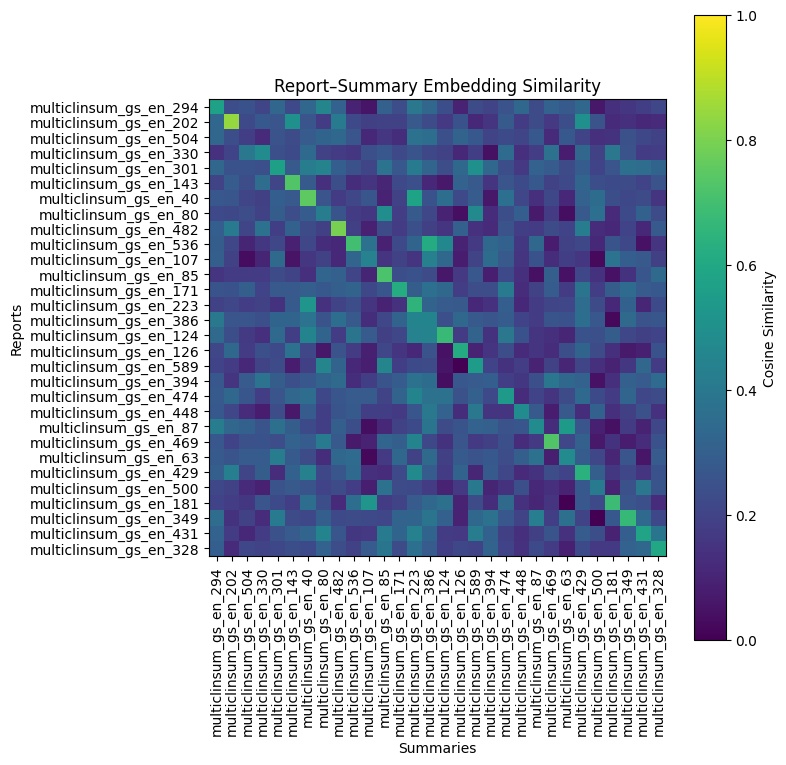

Top 10 report-summary pairs by cosine similarity
Report ID: multiclinsum_gs_en_32
Cosine similarity: 0.9924

REPORT:
this is the case of a 36-year-old woman from the oromia region’s west arsi zone, who presented with a 6-month history of snoring, dysphonia, and cough, as well as significant but unquantified weight loss, fatigue, and low-grade and intermittent fever, for which she had visited various health facilities with no noticeable improvements in her symptoms. she has had diabetes for the past 5 years and is on metformin 500 mg twice a day with poor glycemic control. the physical findings at the presentation, including the throat examination, were unremarkable. the random blood sugar level was 300 mg/dl at the time of presentation (elevated). laryngoscopy revealed an irregular tumor on the anterior one-third of the vocal cord bilaterally, involving the anterior commissure. the biopsy result revealed actinomycotic granules with abscess formation. the patient was then started on pen

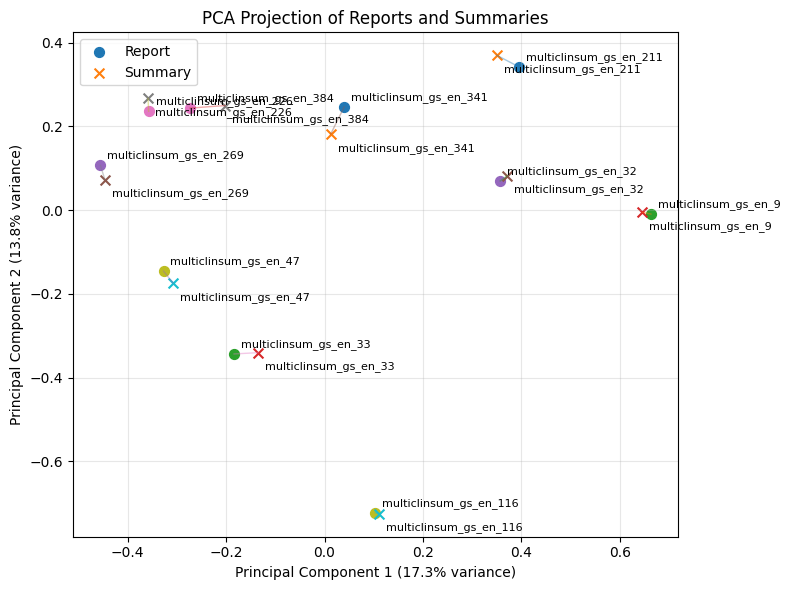

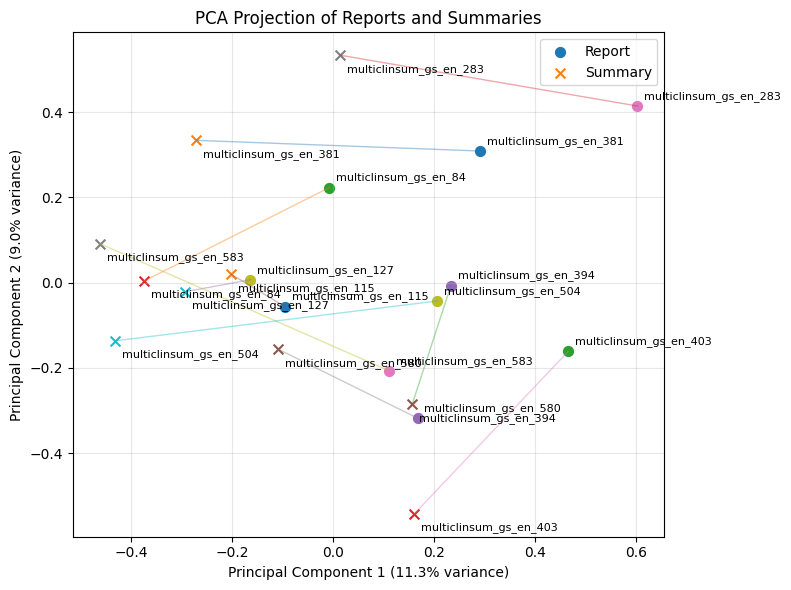

In [8]:
# ==================================================================
# 5 - EMBEDDING GENERATION
# ==================================================================

print("Generating embeddings")

report_embeddings = embedding_model.encode(
    df["report_clean"].tolist(),
    show_progress_bar=True
)

summary_embeddings = embedding_model.encode(
    df["summary_clean"].tolist(),
    show_progress_bar=True
)

print("Embeddings generated.")

print("================================================")
print("EMBEDDINGS OVERVIEW")
print("================================================")

print("embeddings shape", report_embeddings.shape)  #384-dim vector from all-MiniLM-L6-v2
print(report_embeddings[0][:10])  # first 10 values of first sentence
print(summary_embeddings[0][:10])  # first 10 values of first sentence

# ==================================================================
# CHECKING EMBEDDINGS (using similarity matrix of random 30 reports)
# ==================================================================

# take 30 random embeddings
np.random.seed(222)
random_indices = np.random.choice(len(report_embeddings), size=30, replace=False)
report_emb_30 = report_embeddings[random_indices]
summary_emb_30 = summary_embeddings[random_indices]

# create a similarity matrix
similarity_matrix = cosine_similarity(report_emb_30, summary_emb_30)

# visualise heatmap of similarity matrix
plt.figure(figsize=(8, 8))
plt.imshow(similarity_matrix, cmap="viridis", vmin=0, vmax=1)
plt.xlabel("Summaries")
plt.ylabel("Reports")

plt.xticks(range(30), df["report_id"].iloc[random_indices], rotation=90)
plt.yticks(range(30), df["report_id"].iloc[random_indices])
plt.title("Report–Summary Embedding Similarity")
plt.colorbar(label="Cosine Similarity")
plt.tight_layout()
plt.show()

# ==================================================================
# CHECKING EMBEDDINGS (using PCA and visualisation)
# ==================================================================

def plotPCA(report_embeddings, summary_embeddings, report_ids):
  from sklearn.decomposition import PCA

  # Combine report and summary embeddings
  combined_embeddings = np.vstack([report_embeddings, summary_embeddings])

  # Fit PCA jointly
  pca = PCA(n_components=2)
  combined_2d = pca.fit_transform(combined_embeddings)

  # Split the PCA results back into reports and summaries
  len_reports = len(report_embeddings)
  report_2d = combined_2d[:len_reports]
  summary_2d = combined_2d[len_reports:]

  # Create paired plot
  plt.figure(figsize=(8, 6))
  for i in range(len_reports):
      # Coordinates
      report_x, report_y = report_2d[i]
      summary_x, summary_y = summary_2d[i]

      # original report_id
      report_id = report_ids[i]

      # Plot report and summary points
      plt.scatter(report_x, report_y, marker="o", s=50)
      plt.scatter(summary_x, summary_y, marker="x", s=50 )

      # Draw line connecting report and summary
      plt.plot( [report_x, summary_x], [report_y, summary_y], alpha=0.4, linewidth=1 )

      # Label with prefix R for report and S for summary
      plt.annotate( report_id, (report_x, report_y), xytext=(5, 5), textcoords="offset points", fontsize=8  )
      plt.annotate( report_id, (summary_x, summary_y), xytext=(5, -12), textcoords="offset points", fontsize=8  )

  # Labels and formatting
  plt.xlabel(f"Principal Component 1 "
      f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")

  plt.ylabel(f"Principal Component 2 "
      f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

  plt.title("PCA Projection of Reports and Summaries")
  plt.grid(True, alpha=0.3)
  plt.scatter([], [], marker="o", s=50, label="Report")
  plt.scatter([], [], marker="x", s=50, label="Summary")
  plt.legend()
  plt.tight_layout()
  plt.show()

# ==================================================================
# CHECKING ALL EMBEDDINGS (find top-10 and bottom-10 cosine similarity)
# ==================================================================

# create a similarity matrix overall all the data
similarity_all = cosine_similarity(report_embeddings, summary_embeddings)
paired_similarity = np.diag(similarity_all)

report_ids = df["report_id"].values
results = pd.DataFrame({
    "report_id": report_ids,
    "cosine_similarity": paired_similarity
})

top_10 = results.nlargest(10, "cosine_similarity")
bottom_10 = results.nsmallest(10, "cosine_similarity")

# inspect top and bottom content/text

def print_pair(res):
  for _, row in res.iterrows():
    report_id = row["report_id"]
    case = df[df["report_id"] == report_id].iloc[0]

    print("=" * 80)
    print(f"Report ID: {report_id}")
    print(f"Cosine similarity: {row['cosine_similarity']:.4f}")

    print("\nREPORT:")
    print(case["report_clean"])

    print("\nSUMMARY:")
    print(case["summary_clean"])
print("=" * 80)
print("Top 10 report-summary pairs by cosine similarity")
print_pair(top_10)
print("=" * 80)
print("Bottom 10 report-summary pairs by cosine similarity")
print_pair(bottom_10)

#### Plot PCA for top_10 cosine similarities ####

# Get report IDs from top_10
top_ids = top_10["report_id"].values

# Find POSITION of each report in the DataFrame
top_indices = np.where(df["report_id"].isin(top_ids))[0]

# Get the corresponding embeddings
top_report_embeddings = report_embeddings[top_indices]
top_summary_embeddings = summary_embeddings[top_indices]

# Make sure IDs are in the same order as the embeddings
top_ids = df["report_id"].iloc[top_indices].values

# Plot PCA for top_10 cosine similarities
plotPCA(
    top_report_embeddings,
    top_summary_embeddings,
    top_ids
)

#### Plot PCA for bottom_10 cosine similarities ####

# Get report IDs from bottom_10
bot_ids = bottom_10["report_id"].values

# Find POSITION of each report in the DataFrame
bot_indices = np.where(df["report_id"].isin(bot_ids))[0]

# Get the corresponding embeddings
bottom_report_embeddings = report_embeddings[bot_indices]
bottom_summary_embeddings = summary_embeddings[bot_indices]

# Make sure IDs are in the same order as the embeddings
bot_ids = df["report_id"].iloc[bot_indices].values
# Plot PCA for bottom_10 cosine similarities
plotPCA(
    bottom_report_embeddings,
    bottom_summary_embeddings,
    bot_ids
)



In [14]:
# ==================================================================
# 6 - METRIC COMPUTATION
# ==================================================================

# ------------------------------------------------------------------
# ROUGE-L
# ------------------------------------------------------------------

rouge_scorer_model = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_scores = []

for report, summary in zip(df["report_clean"], df["summary_clean"]):
    score = rouge_scorer_model.score(report, summary)
    rouge_scores.append(score["rougeL"].fmeasure)
df["ROUGE_L"] = rouge_scores
print("ROUGE-L completed")

# ------------------------------------------------------------------
# BERTScore
# ------------------------------------------------------------------

P, R, F1 = bertscore(
    df["summary_clean"].tolist(),
    df["report_clean"].tolist(),
    lang="en",
    verbose=True
)
df["BERTScore"] = F1.numpy()
print("BERTScore completed")

# ------------------------------------------------------------------
# ENTITY RECALL + ENTITY LOSS
# ------------------------------------------------------------------

def compute_entity_recall(report_entities, summary_entities):
    report_set = set(report_entities)
    summary_set = set(summary_entities)
    if len(report_set) == 0:
        return 0
    overlap = report_set.intersection(summary_set)
    return len(overlap) / len(report_set)

entity_recalls = []

for report_entities, summary_entities in zip(df_NER["report_entities"], df_NER["summary_entities"]):
    recall = compute_entity_recall(report_entities, summary_entities)
    entity_recalls.append(recall)
df["Entity_Recall"] = entity_recalls

# NB information loss
df["NER_Loss"] = 1 - df["Entity_Recall"]
print("Entity loss completed")

# ------------------------------------------------------------------
# JENSEN-SHANNON DIVERGENCE
# ------------------------------------------------------------------

vectorizer = CountVectorizer(stop_words="english")

def compute_js_divergence(text1, text2):
    vectors = vectorizer.fit_transform( [text1, text2] )
    v1 = vectors.toarray()[0] + 1e-10
    v2 = vectors.toarray()[1] + 1e-10
    p = v1 / np.sum(v1)
    q = v2 / np.sum(v2)
    return jensenshannon(p, q)

js_scores = []

for report, summary in zip(df["report_clean"], df["summary_clean"]):
    js = compute_js_divergence(report, summary)
    js_scores.append(js)
df["JS_Divergence"] = js_scores
print("JS_Divergence completed")

## ???? also try scipy jensenshannon ?????

# ------------------------------------------------------------------
# ENTROPY LOSS
# ------------------------------------------------------------------

def compute_entropy(text):
    words = text.split()
    counts = Counter(words)
    probabilities = np.array( list(counts.values()) )
    probabilities = probabilities / probabilities.sum()
    return entropy(probabilities)   #entropy from scipy.stats

entropy_losses = []

for report, summary in zip( df["report_clean"], df["summary_clean"] ):
    report_entropy = compute_entropy(report)
    summary_entropy = compute_entropy(summary)
    if report_entropy == 0:
        entropy_losses.append(0)
    else:
        loss = 1 - ( summary_entropy / report_entropy  )
        entropy_losses.append(loss)
df["Entropy_Loss"] = entropy_losses
print("Entropy_Loss completed")

# ------------------------------------------------------------------
# EMBEDDING COSINE SIMILARITY
# ------------------------------------------------------------------

cosine_scores = []

for report_emb, summary_emb in zip(report_embeddings, summary_embeddings):
  similarity = cosine_similarity([report_emb], [summary_emb])[0][0]
  cosine_scores.append(similarity)
df["Embedding_Cosine"] = cosine_scores
print("Embedding_Cosine completed")

print(df["Embedding_Cosine"].head())


# ------------------------------------------------------------------
# Estimate mutual information between two embeddings
# ------------------------------------------------------------------

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

def compute_mutual_information(report_embeddings, summary_embeddings):
    # Convert to numpy arrays
    x = np.array(report_embeddings)
    y = np.array(summary_embeddings)

    # Reshape
    x = x.reshape(1, -1)
    y = y.reshape(-1)

    # Standardise
    scaler = StandardScaler()
    x = scaler.fit_transform(x.T).T

    # Estimate MI
    mi = mutual_info_regression( X=x.T, y=y, discrete_features=False  )

    # Mean MI across dimensions
    return np.mean(mi)


# ------------------------------------------------------------
# Mutual information estimator
# ------------------------------------------------------------

# def compute_mutual_information(report_embeddings, summary_embeddings):
#     x = np.array(report_embeddings).reshape(-1, 1)
#     y = np.array(summary_embeddings).reshape(-1, 1)
#     return mi(x, y)

mi_losses = []

for report_emb, summary_emb in zip(report_embeddings, summary_embeddings):
  mi_score = compute_mutual_information(report_emb, summary_emb)
  # Convert MI into loss score, higher MI = lower information loss
  info_loss = np.exp(-mi_score)
  mi_losses.append(info_loss)
df["MI_Information_Loss"] = mi_losses
print("MI_Information_Loss completed")

# # ------------------------------------------------------------------
# # NMI LOSS
# # ------------------------------------------------------------------

# print("Normalise Mutual Information")

# nmi_scores = []
# info_loss_percentages = []

# for report, summary in zip( df["report_clean"], df["summary_clean"] ):
#     nmi = normalized_mutual_info_score(report, summary)
#     nmi_scores.append(nmi)
#     # Calculate relative information loss
#     info_loss_perc = (1 - nmi) * 100
#     info_loss_percentages.append(info_loss_perc)
# df["NMI"] = nmi_scores
# df["IL%"] = info_loss_percentages


# ==================================================================
# 6. FINAL INFORMATION LOSS SCORE
# ==================================================================

print("Computing final Information Loss Score\n")

"""
Weighted composite score, Adjust weights experimentally later
"""

alpha = 0.35   # NER loss
beta = 0.25    # JS divergence
gamma = 0.20   # entropy loss
delta = 0.20   # embedding semantic loss

df["Information_Loss_Score"] = (
    alpha * df["NER_Loss"]
    + beta * df["MI_Information_Loss"]
    + gamma * (1 - df["BERTScore"])
)

# ctrl /
df["Clinical_Information_Loss"] = (
    alpha * df["MI_Information_Loss"]
    + beta * (1 - df["BERTScore"])
    + gamma * df["NER_Loss"]
)
print("Final Information Loss Score completed")


ROUGE-L completed


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/19 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/10 [00:00<?, ?it/s]

done in 176.33 seconds, 3.36 sentences/sec
BERTScore completed
Entity loss completed
JS_Divergence completed
Entropy_Loss completed
Embedding_Cosine completed
0    0.583040
1    0.492280
2    0.757233
3    0.713271
4    0.562696
Name: Embedding_Cosine, dtype: float32
MI_Information_Loss completed
Computing final Information Loss Score

Final Information Loss Score completed


SUMMARY STATISTICS
        ROUGEdiff    BERTdiff  Cosinediff    NER_Loss  JS_Divergence  \
count  592.000000  592.000000  592.000000  592.000000     592.000000   
mean     0.801937    0.154044    0.379924    0.872007       0.655569   
std      0.108533    0.024655    0.136730    0.128816       0.071948   
min      0.163435    0.037529    0.007555    0.000000       0.241775   
25%      0.765335    0.139980    0.289823    0.833333       0.617748   
50%      0.825068    0.157163    0.372376    0.909091       0.667604   
75%      0.875548    0.170051    0.462145    0.950305       0.703833   
max      0.995855    0.228770    0.816027    1.000000       0.810370   

       Entropy_Loss  MI_Information_Loss  Information_Loss_Score  
count    592.000000           592.000000              592.000000  
mean       0.199965             0.754472                0.524629  
std        0.078869             0.120315                0.068207  
min       -0.816503             0.119943                0.118170

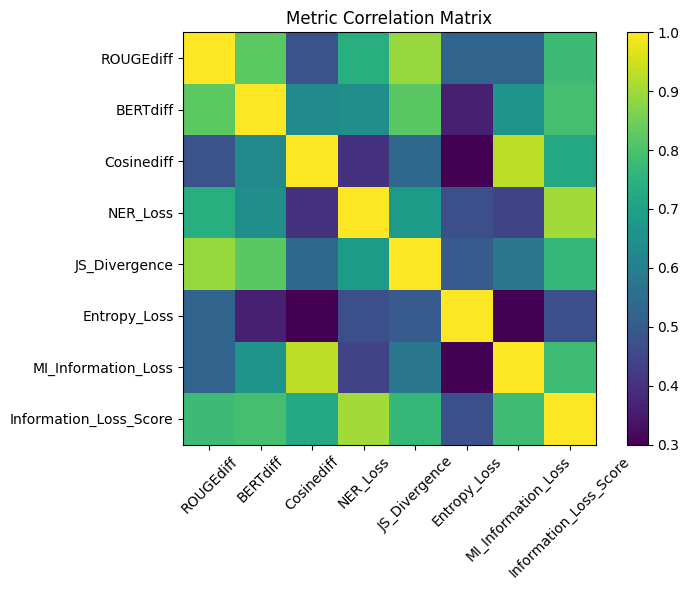

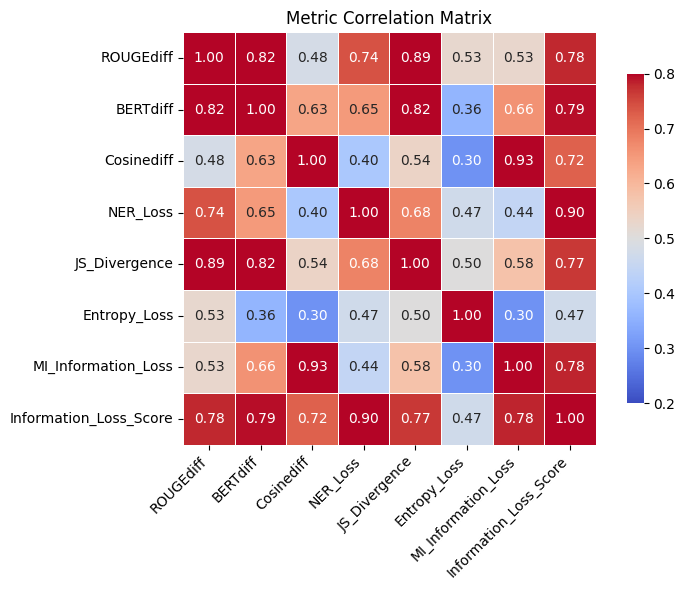

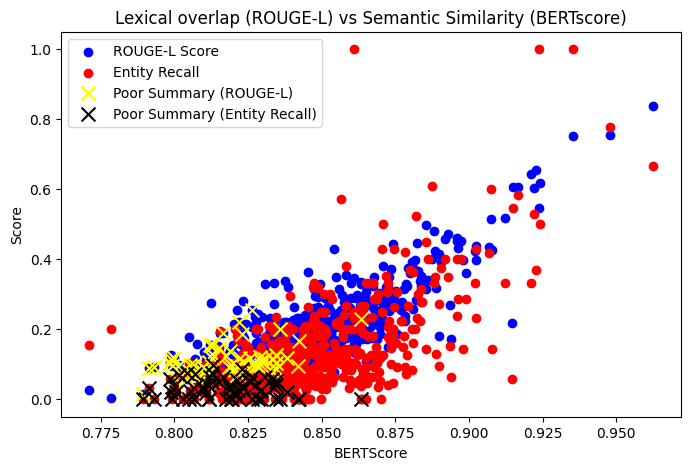

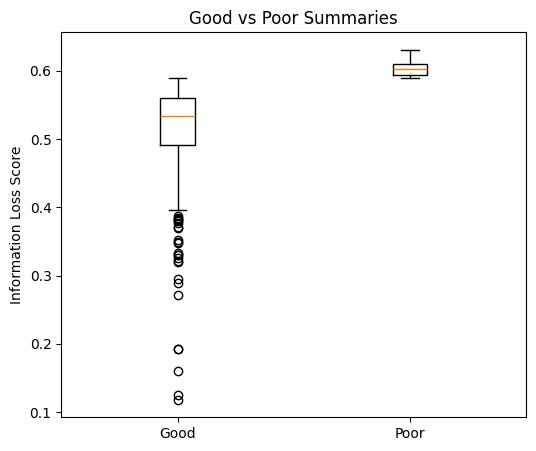

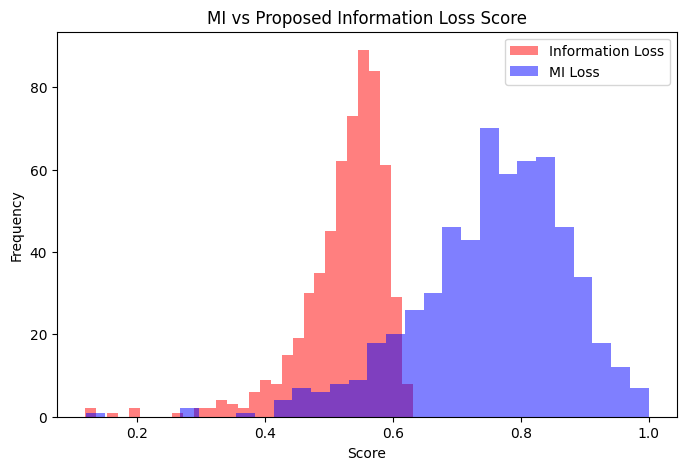

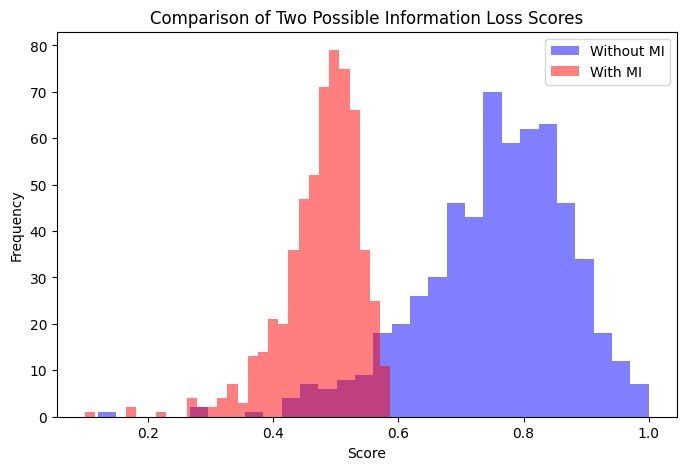

RESULTS SAVED as multiclinsum_information_loss_results.csv


In [15]:

# ==================================================================
# 7 - ANALYSIS
# ==================================================================

#convert ROUGE, BERT and cosine into differences instead of similarities
df['ROUGEdiff'] = 1- df['ROUGE_L']
df['BERTdiff'] = 1- df['BERTScore']
df['Cosinediff'] = 1- df['Embedding_Cosine']
print("SUMMARY STATISTICS")
metrics = [
    "ROUGEdiff",
    "BERTdiff",
    "Cosinediff",
    "NER_Loss",
    "JS_Divergence",
    "Entropy_Loss",
    "MI_Information_Loss",
    "Information_Loss_Score"
]
summary_stats = df[metrics].describe()
print(summary_stats)
summary_stats.to_csv('summary_statistics.csv')

# DETECT HIGH-LOSS SUMMARIES

print("THRESHOLD ANALYSIS")
threshold = df["Information_Loss_Score"].quantile(0.90)
print("High-loss threshold:", threshold)
df["Poor_Summary"] = (df["Information_Loss_Score"] > threshold)
print("Poor summaries detected:", df["Poor_Summary"].sum())


# ==================================================================
# 8 - VISUALISATIONS
# ==================================================================


# METRIC CORRELATION HEATMAP
print("CORRELATION MATRIX")
correlation_matrix = df[metrics].corr()
print(correlation_matrix)

# PLOT
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.colorbar()
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.show()

# alternative in seaborn
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # show values in cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",
    vmin=0.2,            # lower limit
    vmax=0.8,            # upper limit
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.show()


# BERTScore vs ROUGE-L scores AND Entity Recall
# These are how similar the full reports and summaries are

plt.figure(figsize=(8, 5))
poor = df[df["Poor_Summary"] == True]
plt.scatter(df["BERTScore"], df["ROUGE_L"], color="b", label="ROUGE-L Score")
plt.scatter(df["BERTScore"], df["Entity_Recall"], color="r", label="Entity Recall")
# Highlight poor summaries with black crosses
plt.scatter(poor["BERTScore"], poor["ROUGE_L"], color="yellow", marker="x", s=100, label="Poor Summary (ROUGE-L)")
plt.scatter(poor["BERTScore"], poor["Entity_Recall"], color="black", marker="x", s=100, label="Poor Summary (Entity Recall)")
plt.xlabel("BERTScore")
plt.ylabel("Score")
plt.title("Lexical overlap (ROUGE-L) vs Semantic Similarity (BERTscore)")
plt.legend()
plt.show()


# BOXPLOT

plt.figure(figsize=(6, 5))
plt.boxplot([
    df[ df["Poor_Summary"] == False ]["Information_Loss_Score"],
    df[ df["Poor_Summary"] == True ]["Information_Loss_Score"]
])
plt.xticks([1, 2], ["Good", "Poor"])
plt.ylabel("Information Loss Score")
plt.title("Good vs Poor Summaries")
plt.show()


# HISTOGRAM of BOTH my Information Loss Score and MI

plt.figure(figsize=(8, 5))
plt.hist(df["Information_Loss_Score"], bins=30, color="r", label="Information Loss", alpha=0.5 )
plt.hist(df["MI_Information_Loss"], bins=30, color="b", label="MI Loss", alpha=0.5 )
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("MI vs Proposed Information Loss Score")
plt.legend()
plt.show()


# HISTOGRAM of two different information loss scores

plt.figure(figsize=(8, 5))
plt.hist(df["MI_Information_Loss"], bins=30, color="b", label="Without MI", alpha=0.5 )
plt.hist(df["Clinical_Information_Loss"], bins=30, color="r", label="With MI", alpha=0.5 )
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Comparison of Two Possible Information Loss Scores")
plt.legend()
plt.show()


# ==================================================================
# 9 - SAVE RESULTS
# ==================================================================

OUTPUT_FILE = "multiclinsum_information_loss_results.csv"
df.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)
